## This notebook performs lambda TV sweeps across different allen cahn solutions that have varying curvatures.

In [5]:
import numpy as np
import sys

sys.path.append('..')  # add project root

import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import Datasets.load_mat_as_flat as lmf
import os

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

import importlib
importlib.reload(mlps)
importlib.reload(trainer)
importlib.reload(hlprs)
importlib.reload(lmf)

<module 'Datasets.load_mat_as_flat' from 'c:\\Users\\Ethan\\Desktop\\Research\\pde_stuff\\ethan_work\\..\\Datasets\\load_mat_as_flat.py'>

In [6]:
lam_pde = 1.0

lr_tv = 1e-4
lr_pde = 1e-3

lam_reg = 0.5
lam_data = 10.0

# hyperparameters for data generation
# data = sio.loadmat("path")
noise=0.1
nu=0.02
stride_t=1
stride_x=1
part_num=1
which_part=1
seed=1432

selected_derivs = ('u','u_x','u_xx')

# correct_coeffs = [0.0, 0.0, nu, -1.0]  # corresponds to the correct PDE: u_t + u*u_x - nu*u_xx = 0
correct_coeffs = [5, 0, 0.001, 0, -5]# u_t = 0.001u_xx + 5u - 5u^3


lr = 1e-3
batch_size = 1000
# epoch = data["t"].shape[0] * data["x"].shape[1]
# steps_per_epoch = epoch // batch_size
steps = 60 #6000
log_every = 500

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")




Using device: cuda


In [7]:


def tv1d_space_uxx_penalize(u_fn, t, x, eps=1e-6):

    # Returns E[ sqrt( (du/dx)^2 + eps^2 ) ]
    u = u_fn(t, x)
    ones = torch.ones_like(u)
    ux = torch.autograd.grad(
        u, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    uxx = torch.autograd.grad(
        ux, x,
        grad_outputs=ones,
        create_graph=True,
        retain_graph=True,
    )[0]
    tv = torch.sqrt(uxx**2 + eps**2)
    return tv.mean()

def make_models():
    u_model = mlps.SirenMLP(hidden_layers=4, hidden_size=64, first_omega_0=1.0, hidden_omega_0=1.0)
    symnet = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, num_layers=2, bias=False) # we need 2 linear layers to create the cubic terms
    return u_model, symnet

def make_trainer(u_model, symnet, lam_tv):
    train_config = trainer.TrainerConfig(
        lr=lr,
        lr_tv=lr_tv,
        lr_pde=lr_pde,
        lambda_pde= lam_pde,
        lambda_reg=lam_reg,
        lambda_tv= lam_tv,
        lambda_data=lam_data,
        lambda_tv_mask_fn = None,
        lambda_pde_mask_fn = None,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    return trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

In [9]:
output_path_outline = "../ethan_work/AC_different_ICs_sweeps/curvature_sweep_results.json"

mat_paths = [
    "../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_0.05.mat",
    "../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_0.1.mat",
    "../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_0.2.mat",
    "../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_0.4.mat",
    "../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_0.8.mat",
    "../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_1.0.mat",
    "../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_2.0.mat"
]
path_eps_vals = [0.05, 0.1, 0.2, 0.4, 0.8, 1.0, 2.0]


for path, epsilon in zip(mat_paths, path_eps_vals):
    print(f"PROCESSING {path}...")
    #create a new dataset for each mat file path
    partitions = lmf.load_burgers_mat_as_flat(mat_path=path,
                                                noise_level=noise, 
                                                stride_t=stride_t, 
                                                stride_x=stride_x, 
                                                seed=seed, 
                                                quantile_splits=part_num, 
                                                return_partitions=True)

    key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
    t_np, x_np, y_np, y_noisy_np, N = partitions[key]
    # torch tensors
    t_torch       = torch.from_numpy(t_np).to(device)
    x_torch       = torch.from_numpy(x_np).to(device)
    y_clean_torch = torch.from_numpy(y_np).to(device)
    y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

    lam_tv_sweeps = [0, 10e-8, 10e-7, 10e-6, 10e-5, 10e-4, 10e-3, 10e-2, 10e-1]
    for lam_tv in lam_tv_sweeps:
        # for each lambda_tv, we will train a model and save the results in a JSON
        print(f"Training model with lamda_tv={lam_tv}")
        u_model, symnet = make_models()
        train = make_trainer(u_model, symnet, lam_tv)

        #train model 
        out = []
        for i in range(6000): 
            t,x,u_noisy,u_clean = hlprs.make_batch(batch_size=batch_size,
                                                t_torch=t_torch,
                                                x_torch=x_torch,
                                                y_clean=y_clean_torch,
                                                y_noisy=y_noisy_torch)
            out = train.step(t=t,x=x,u_noisy=u_noisy,u_clean=u_clean, tv_fn=tv1d_space_uxx_penalize)
        
        hlprs.snapshot_comp(train.u, 
                            stride_x, 
                            stride_t, 
                            y_noisy_np, 
                            y_np, 
                            t_np, 
                            x_np, 
                            snap_no=10, 
                            folder=f"../ethan_work/AC_diff_ICs_new/eps_{epsilon}", 
                            lam_tv=lam_tv
        )[:0]
        
        # save model instance to JSON
        hlprs.save_to_json(train, out, correct_coeffs, path=f"../ethan_work/AC_diff_ICs_new/eps_{epsilon}/lam_tv_{lam_tv}.json")

PROCESSING ../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_0.05.mat...
Training model with lamda_tv=0
max_abs_diff = 0.267923
Training model with lamda_tv=1e-07
max_abs_diff = 0.244143
Training model with lamda_tv=1e-06
max_abs_diff = 0.262207
Training model with lamda_tv=1e-05
max_abs_diff = 0.256248
Training model with lamda_tv=0.0001
max_abs_diff = 0.268317
Training model with lamda_tv=0.001
max_abs_diff = 0.206883
Training model with lamda_tv=0.01
max_abs_diff = 0.453429
Training model with lamda_tv=0.1
max_abs_diff = 0.735933
Training model with lamda_tv=1.0
max_abs_diff = 0.978558
PROCESSING ../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_0.1.mat...
Training model with lamda_tv=0
max_abs_diff = 0.301232
Training model with lamda_tv=1e-07
max_abs_diff = 0.333285
Training model with lamda_tv=1e-06
max_abs_diff = 0.318323
Training model with lamda_tv=1e-05
max_abs_diff = 0.32299
Training model with lamda_tv=0.0001
max_abs_diff = 0.32183
Training model with lamda_

KeyboardInterrupt: 

### Below shows a heatmap of the (local) variance at each point, using sliding windows to calculate the variance (i.e. variance at a point (x,t) is calculated from a 5x5 window surrounding the point)

In [3]:
data = sio.loadmat("../Datasets/data/Different_Curvatures/Allen_Cahn_tanh_0.05.mat")
uxx = data["u_xx"]
print(uxx.shape)

(101, 201)


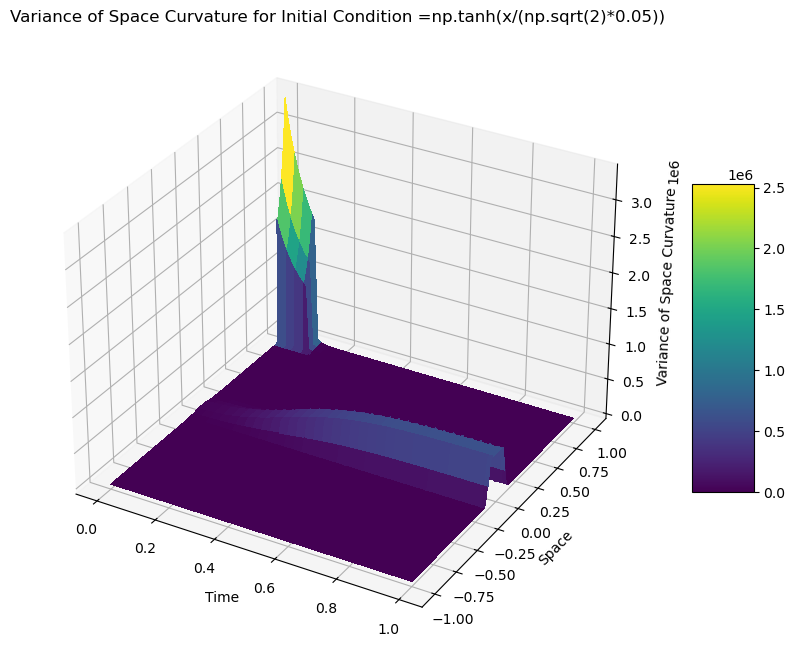

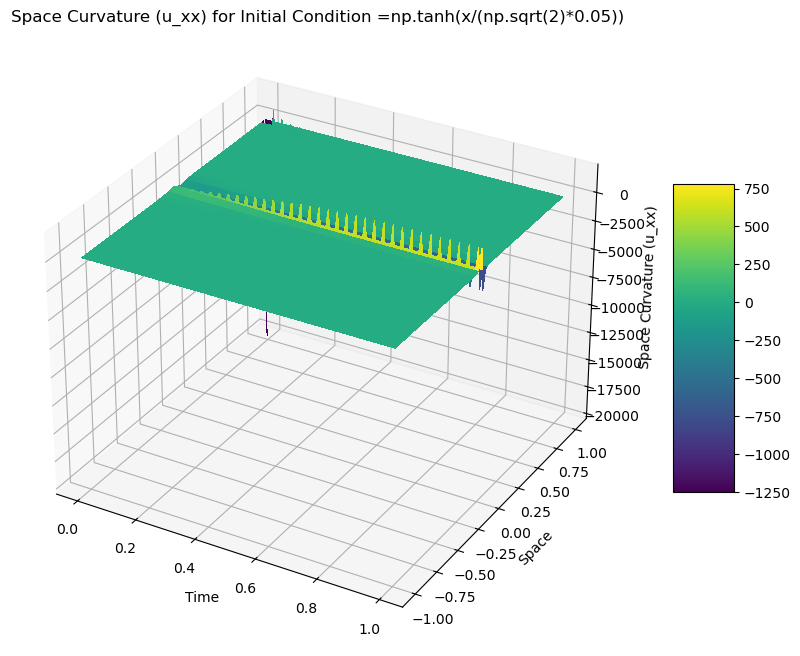

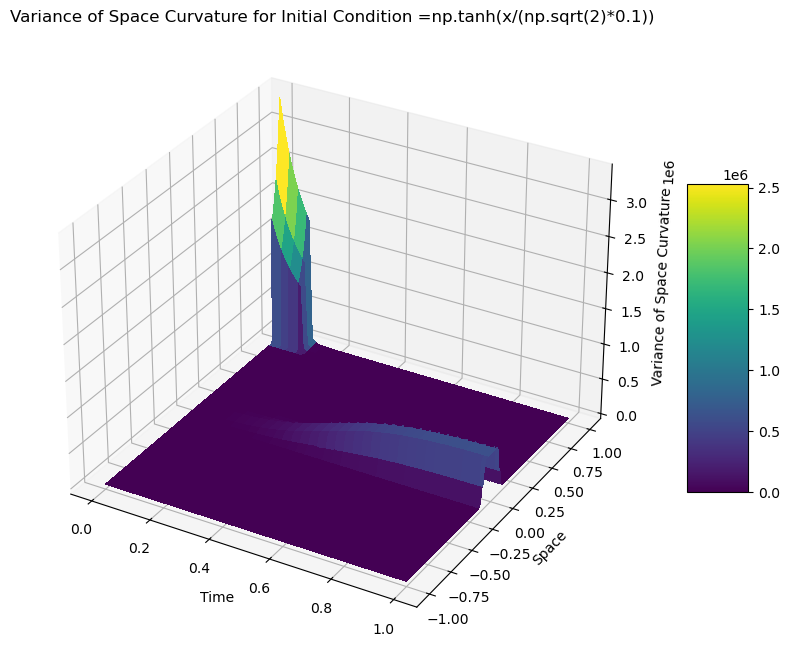

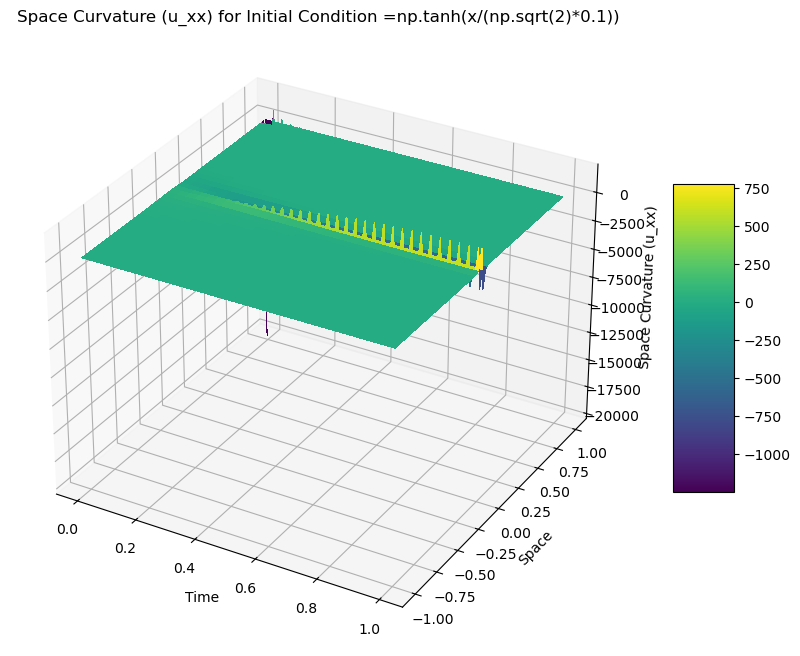

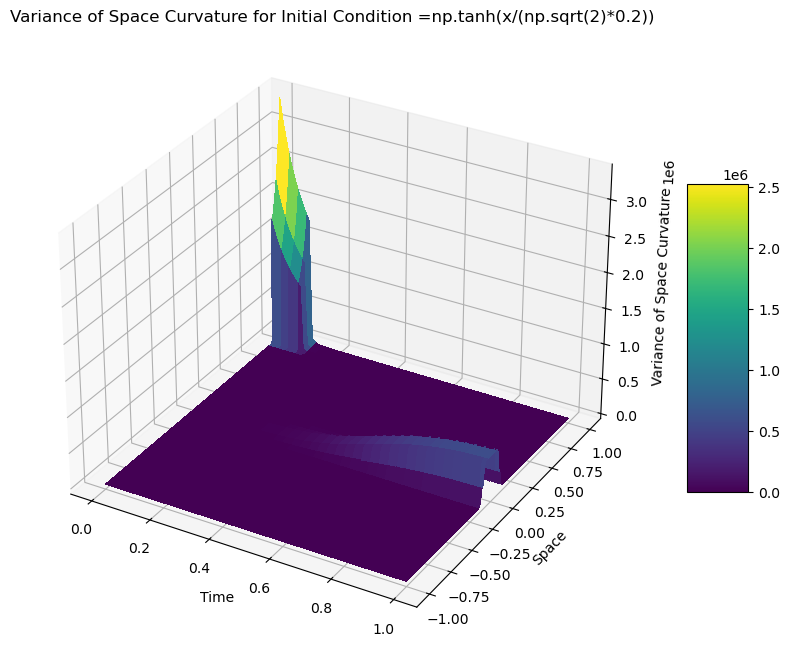

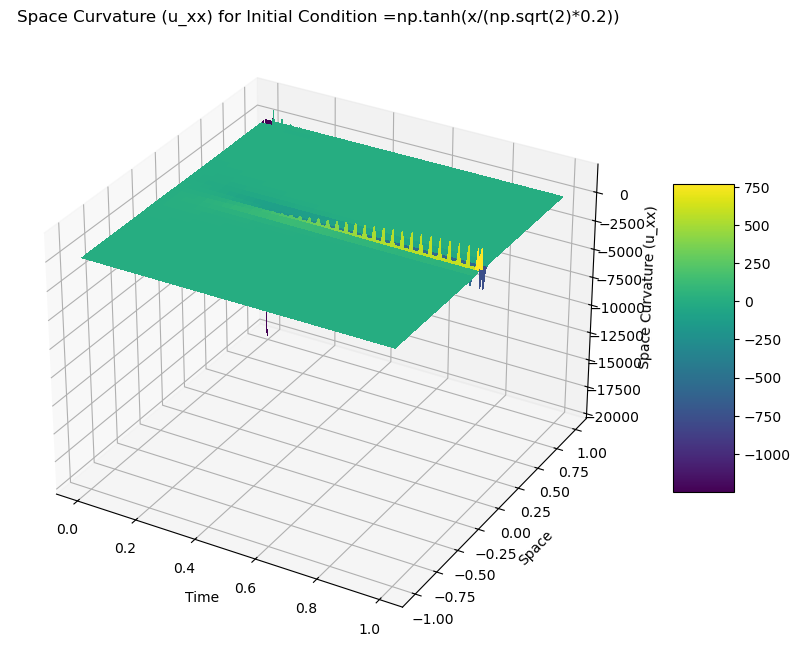

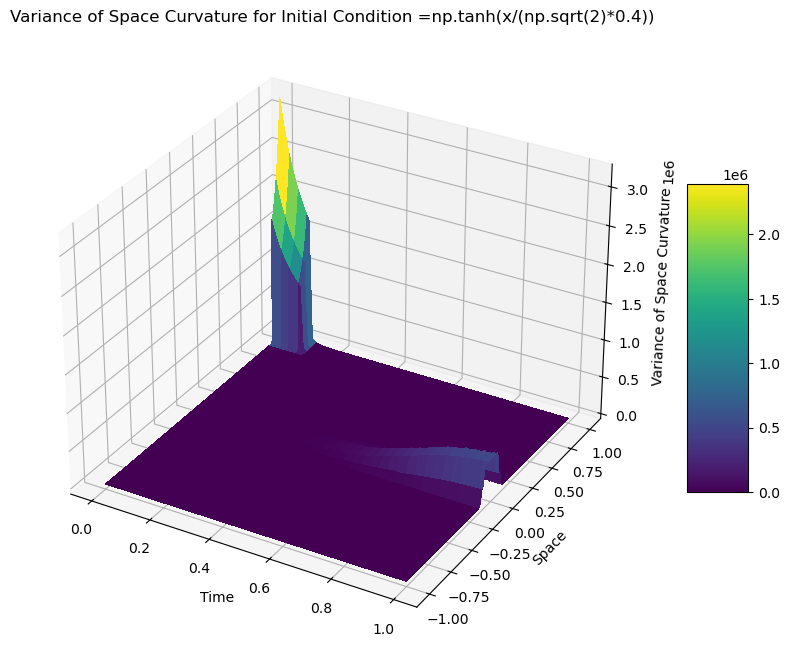

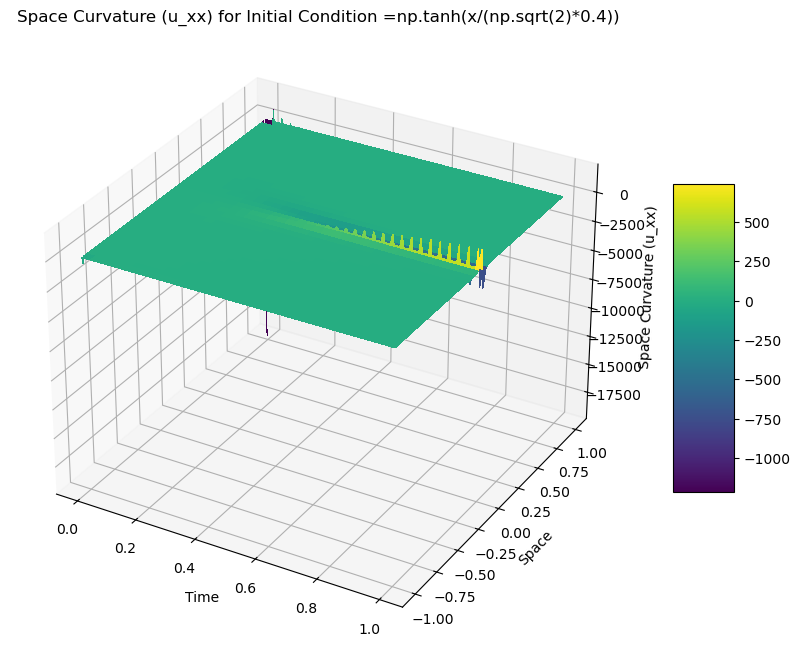

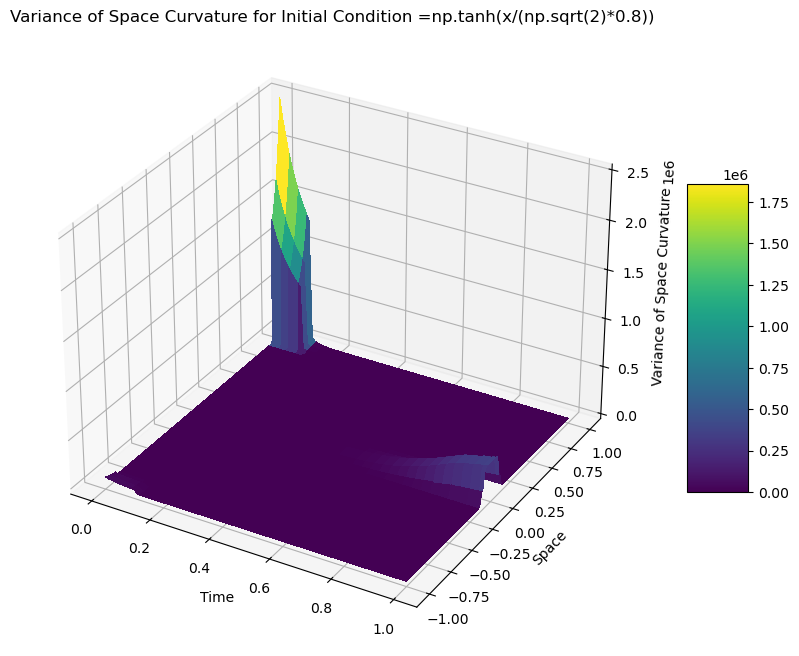

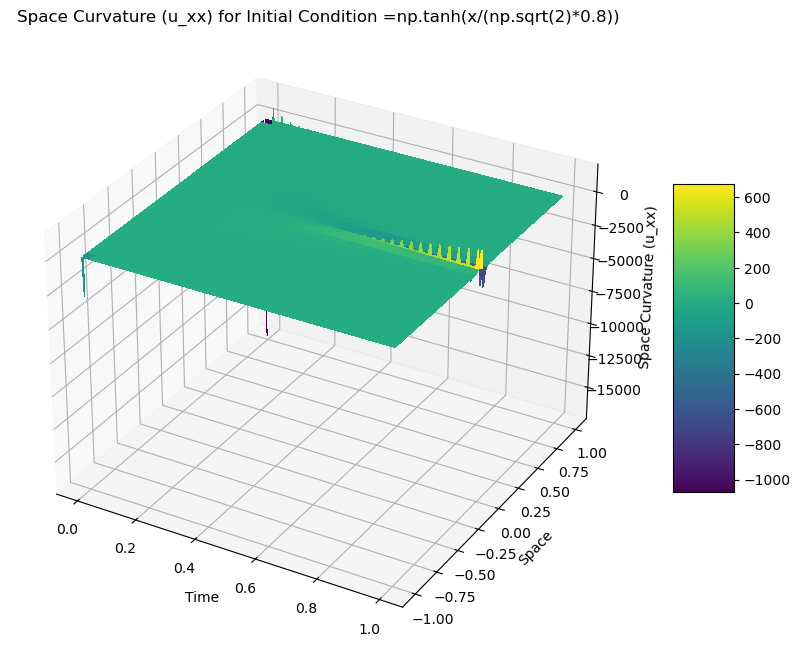

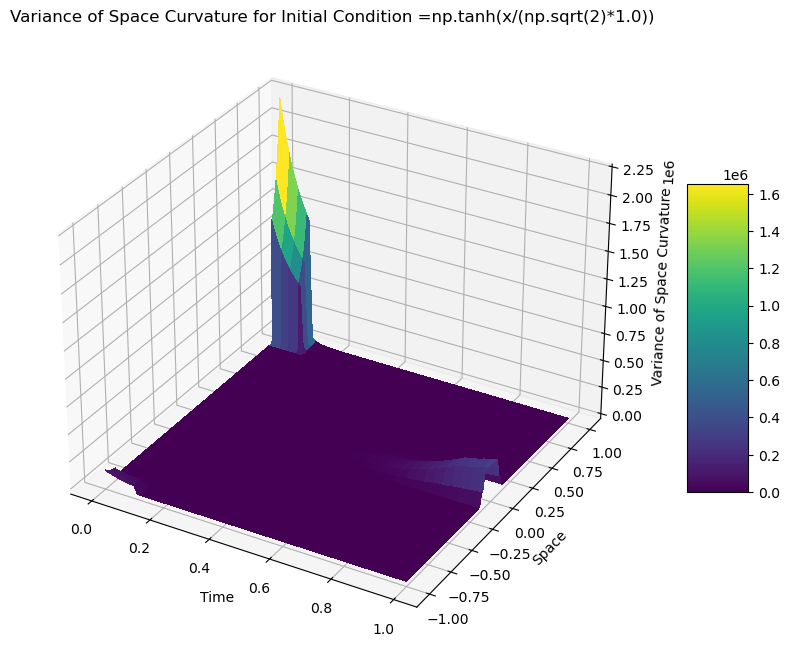

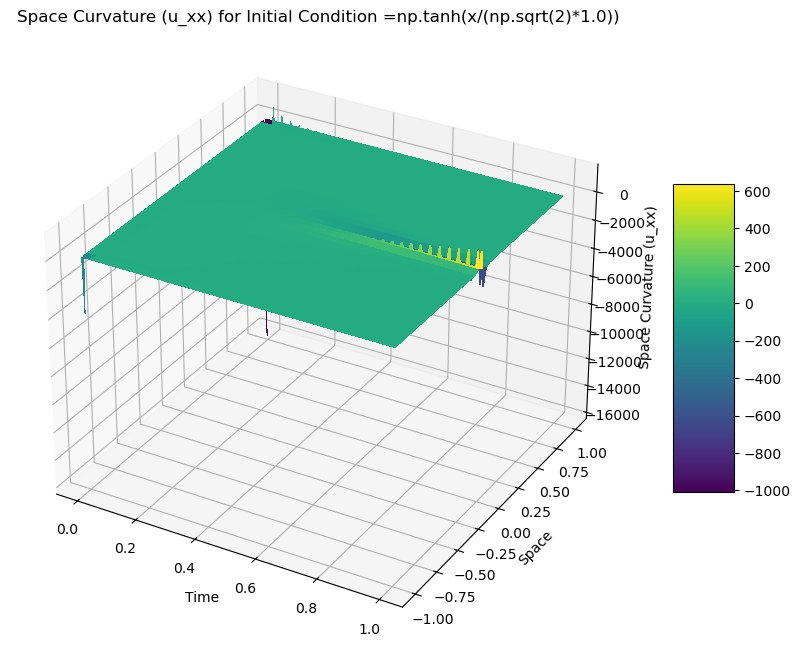

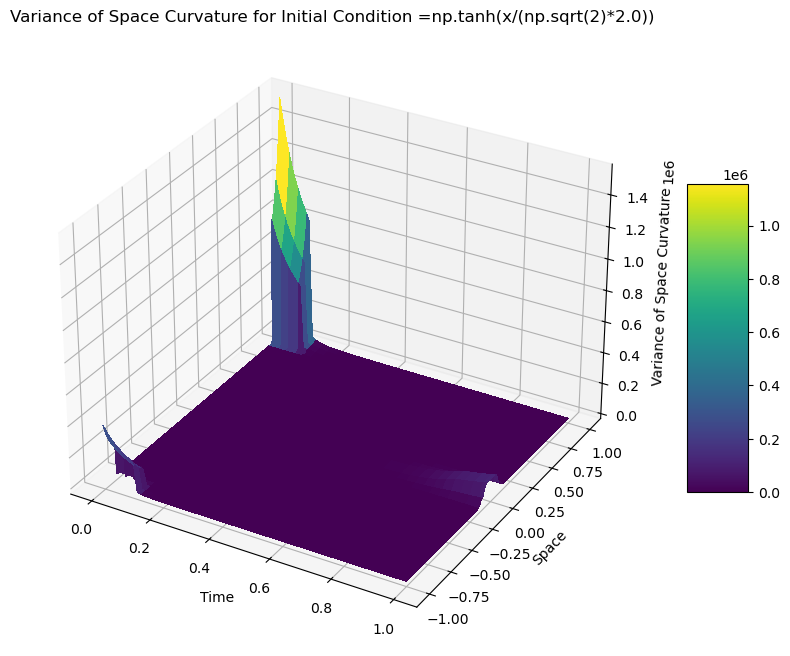

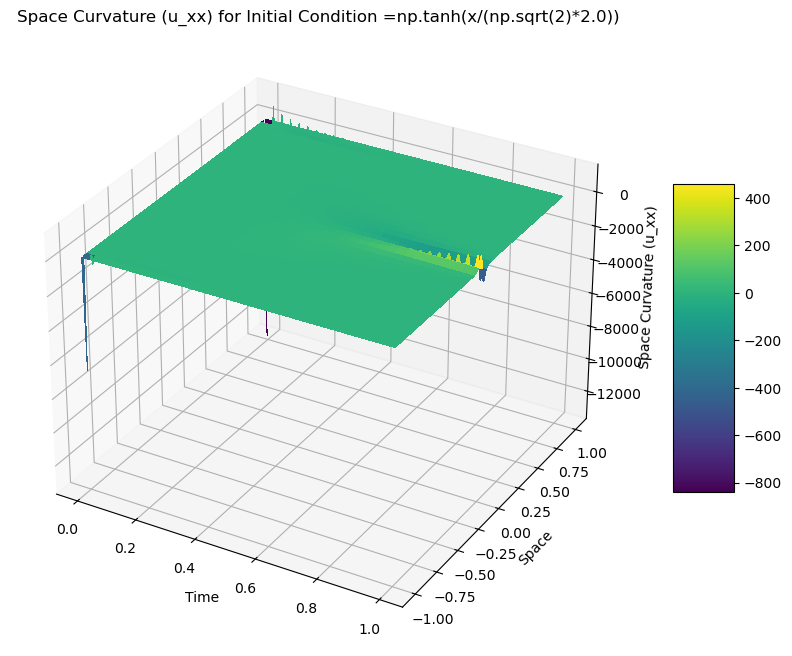

In [ ]:


def get_max_space_curvature(mat_path):
    data = sio.loadmat(mat_path)
    uxx = data['u_xx']  # assuming the .mat file has a variable named 'u_xx'
    return np.max(np.abs(uxx))
def get_max_time_curvature(mat_path):
    data = sio.loadmat(mat_path)
    utt = data['u_tt']  # assuming the .mat file has a variable named 'u_tt'
    return np.max(np.abs(utt))
def get_mean_space_curvature(mat_path):
    data = sio.loadmat(mat_path)
    uxx = data['u_xx']  # assuming the .mat file has a variable named 'u_xx'
    return np.mean(np.abs(uxx))
def get_mean_time_curvature(mat_path):
    data = sio.loadmat(mat_path)
    utt = data['u_tt']  # assuming the .mat file has a variable named 'u_tt'
    return np.mean(np.abs(utt))
def get_mean_curvature(mat_path):
    data = sio.loadmat(mat_path)
    uxx = data['u_xx']  # assuming the .mat file has a variable named 'u_xx'
    utt = data['u_tt']  # assuming the .mat file has a variable named 'u_tt'
    space_curvature = np.abs(uxx)
    time_curvature = np.abs(utt)
    mean_curvature = (space_curvature + time_curvature) / 2
    return np.mean(mean_curvature)
def get_variance_space_curvature(mat_path, window_size=20):
    # this function will compute the variance of the curvature at each point using a sliding window,
    data = sio.loadmat(mat_path)
    uxx = data['u_xx']  # assuming the .mat file has a variable named 'u_xx'
    #implement a sliding window variance computation
    variance_curvature = np.zeros_like(uxx)
    for i in range(uxx.shape[0]):
        for j in range(uxx.shape[1]):
            # define the window boundaries
            i_min = max(i - window_size // 2, 0)
            i_max = min(i + window_size // 2 + 1, uxx.shape[0])
            j_min = max(j - window_size // 2, 0)
            j_max = min(j + window_size // 2 + 1, uxx.shape[1])
            # extract the window
            window = uxx[i_min:i_max, j_min:j_max]
            # compute the variance in the window
            variance_curvature[i, j] = np.var(window)
    return variance_curvature


# now create a dataframe with each column being for a specific mat file, 
# with rows for each curvature metric, optimal lambda_tv (based on final loss), and final loss
import pandas as pd
import json
import scipy.io as sio
path_eps_vals = [0.05, 0.1, 0.2, 0.4, 0.8, 1.0, 2.0]
# results_df = pd.DataFrame(columns=['epsilon=0.05', 'epsilon=0.1', 'epsilon=0.2', 'epsilon=0.4', 'epsilon=0.8', 'epsilon=1.0', 'epsilon=2.0'],
                        #   index=['max_space_curvature', 'max_time_curvature', 'mean_space_curvature', 'mean_time_curvature', 'mean_curvature'])
for eps in path_eps_vals:
    mat_path = f"../Datasets/data/Different_Curvatures/Allen_Cahn_tanh_{eps}.mat"
    # results_df.loc['max_space_curvature', f'epsilon={eps}'] = get_max_space_curvature(mat_path)
    # results_df.loc['max_time_curvature', f'epsilon={eps}'] = get_max_time_curvature(mat_path)
    # results_df.loc['mean_space_curvature', f'epsilon={eps}'] = get_mean_space_curvature(mat_path)
    # results_df.loc['mean_time_curvature', f'epsilon={eps}'] = get_mean_time_curvature(mat_path)
    # results_df.loc['mean_curvature', f'epsilon={eps}'] = get_mean_curvature(mat_path)
    variance_space_curvature = get_variance_space_curvature(mat_path)

    # lam_tv_sweeps = [10e-8, 10e-7, 10e-6, .0001, 0.001, 0.01, 0.1, 1.0]
    # go through the JSON files for this epsilon and find the optimal lambda_tv based on final loss
    # for lam_tv in lam_tv_sweeps:
    #     json_path = f"../ethan_work/AC_different_ICs_sweeps/eps_{eps}/lam_tv_{lam_tv}.json"
    #     if os.path.exists(json_path):
    #         with open(json_path, 'r') as f:
    #             data = json.load(f)
    #             final_loss = data['final_loss']
    #             if 'best_loss' not in results_df.columns or final_loss < results_df.loc['best_loss', f'epsilon={eps}']:
    #                 results_df.loc['best_loss', f'epsilon={eps}'] = final_loss
    #                 results_df.loc['optimal_lambda_tv', f'epsilon={eps}'] = lam_tv
    import matplotlib.pyplot as plt
    import numpy as np

    from matplotlib import cm
    from matplotlib.ticker import LinearLocator

    space_var = np.linspace(-1, 1, variance_space_curvature.shape[1])
    time_var = np.linspace(0, 1, variance_space_curvature.shape[0])
    time_var, space_var = np.meshgrid(time_var, space_var)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 8))
    surf = ax.plot_surface(time_var, space_var, variance_space_curvature.T, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax.set_xlabel('Time')
    ax.set_ylabel('Space')
    ax.set_zlabel('Variance of Space Curvature')
    ax.set_title(f'Variance of Space Curvature for Initial Condition =np.tanh(x/(np.sqrt(2)*{eps}))')
    fig.colorbar(surf, shrink=0.5, aspect=5)

    uxx = sio.loadmat(mat_path)['u_xx']
    space = np.linspace(-1, 1, uxx.shape[1])
    time = np.linspace(0, 1, uxx.shape[0])
    time, space = np.meshgrid(time, space)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 8))
    surf = ax.plot_surface(time, space, uxx.T, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax.set_xlabel('Time')
    ax.set_ylabel('Space')
    ax.set_zlabel('Space Curvature (u_xx)')
    ax.set_title(f'Space Curvature (u_xx) for Initial Condition =np.tanh(x/(np.sqrt(2)*{eps}))')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()







## Analyzing the same thing on the newer Allen-Cahn datasets which use ghost points for enforicing neumann BCs

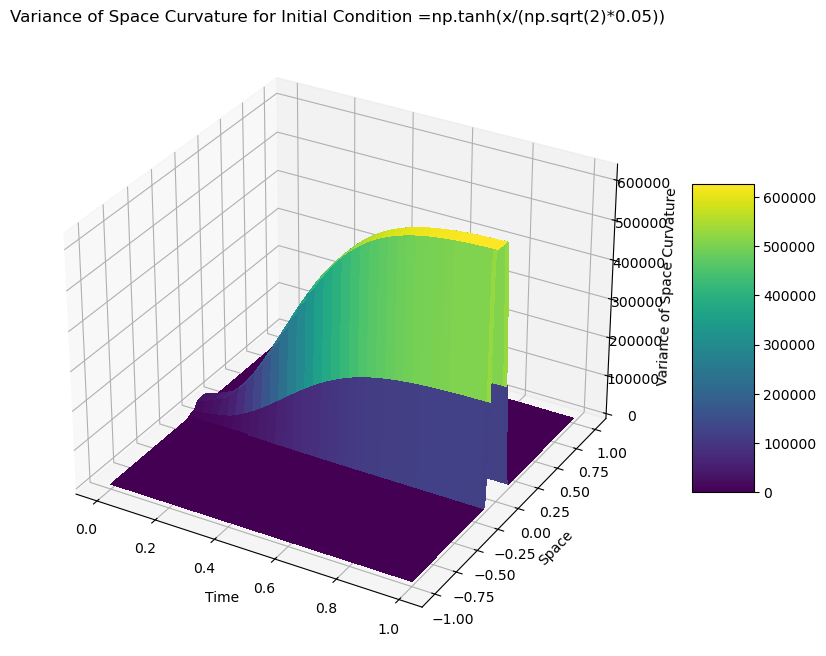

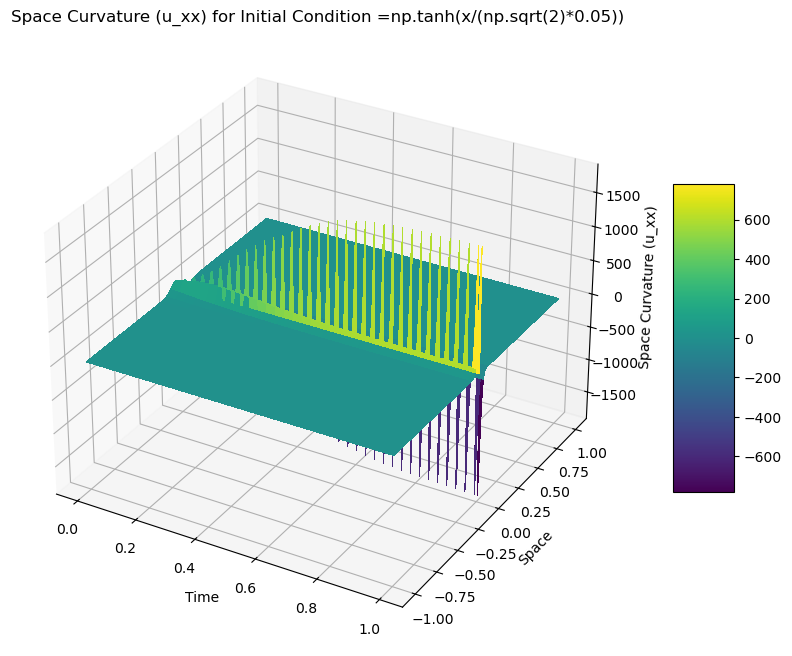

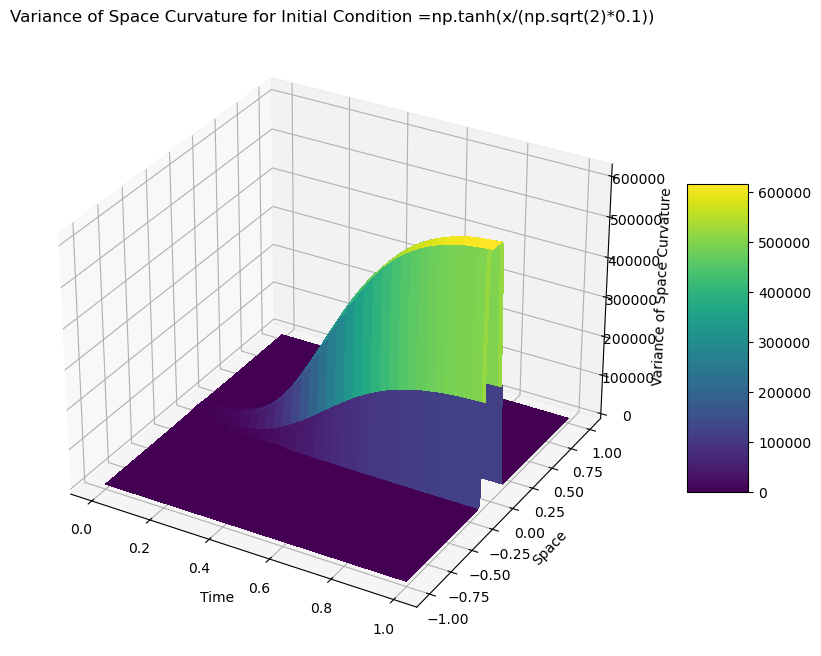

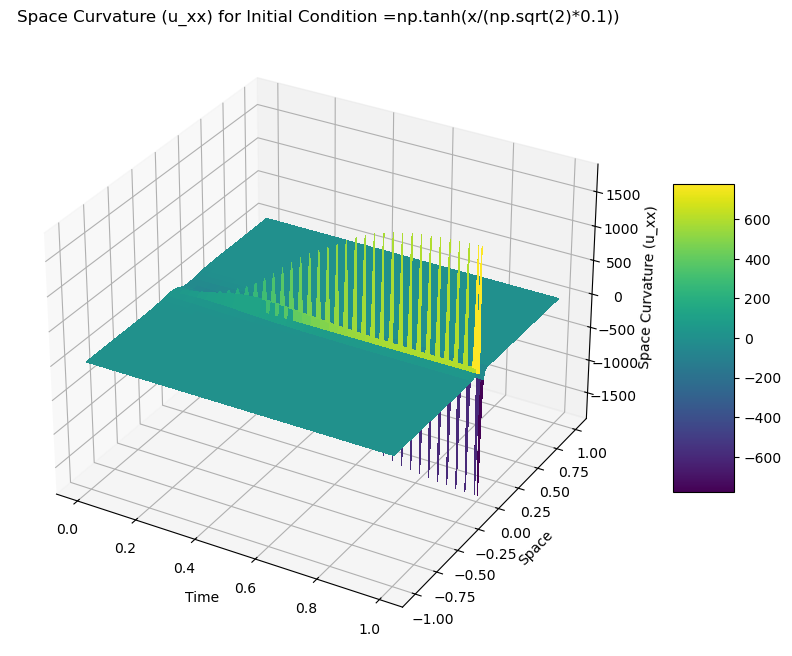

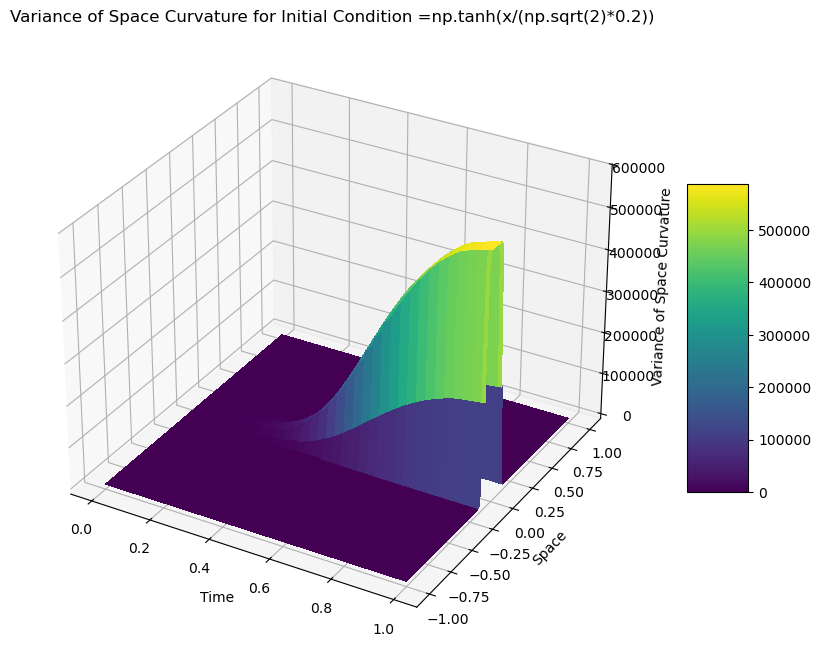

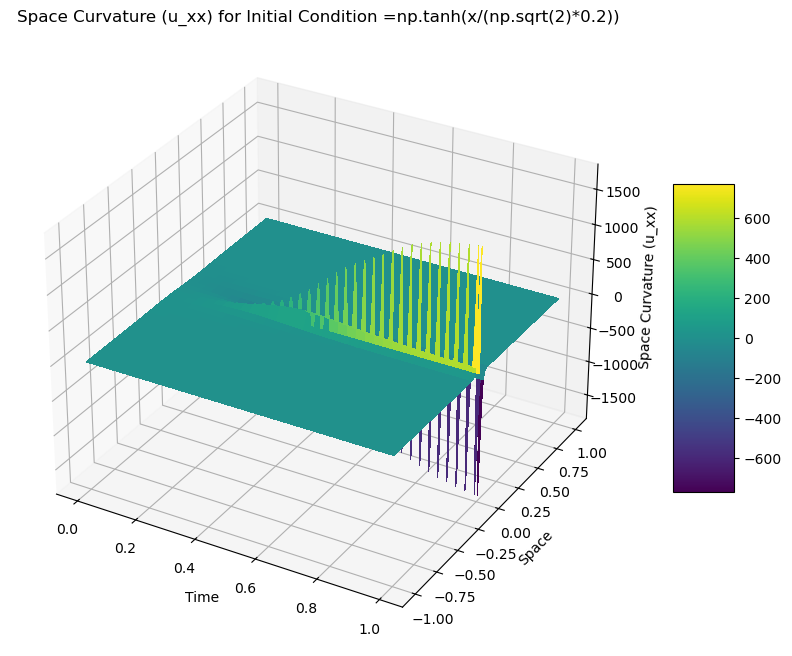

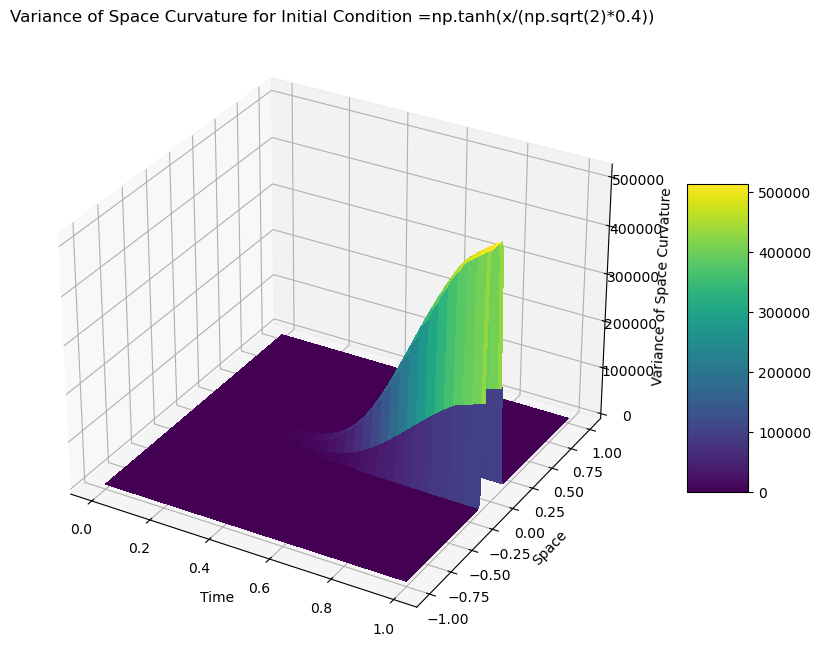

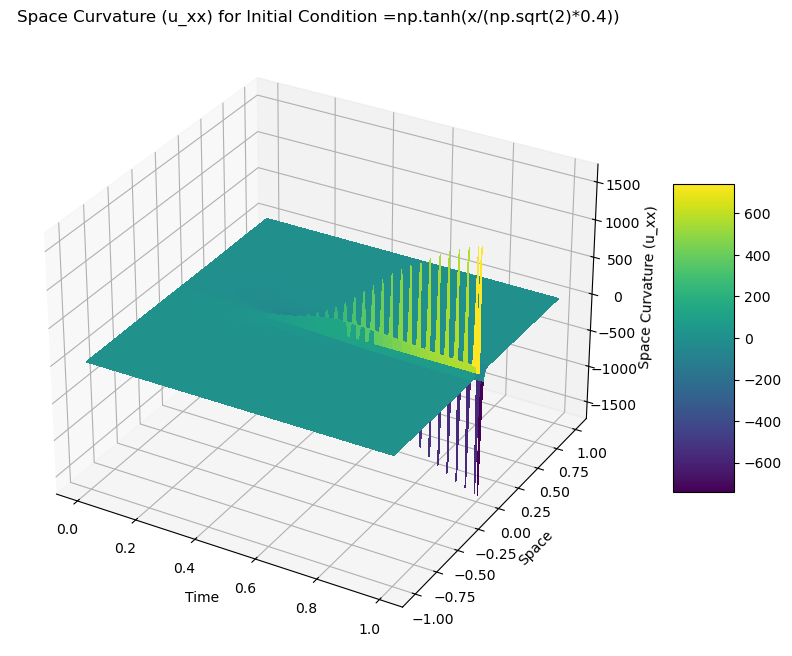

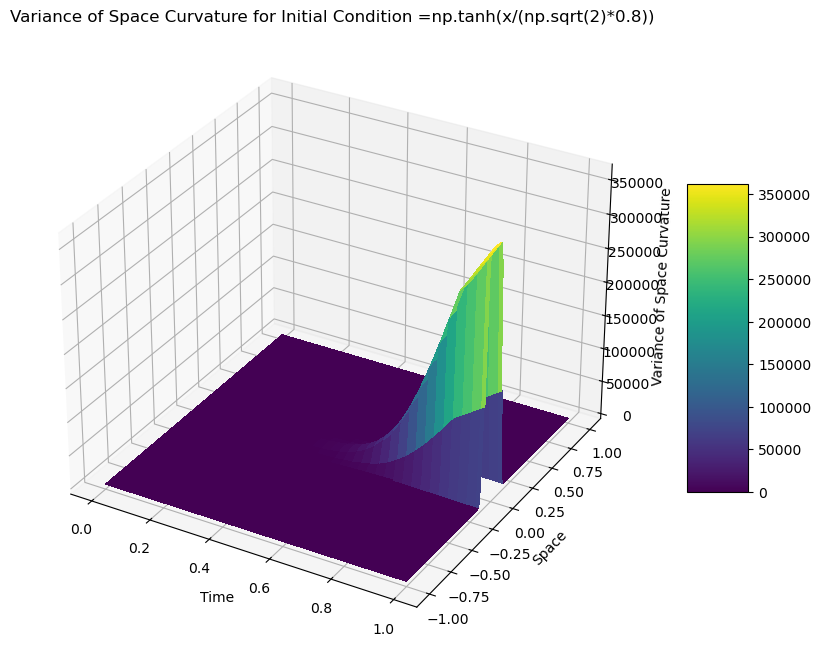

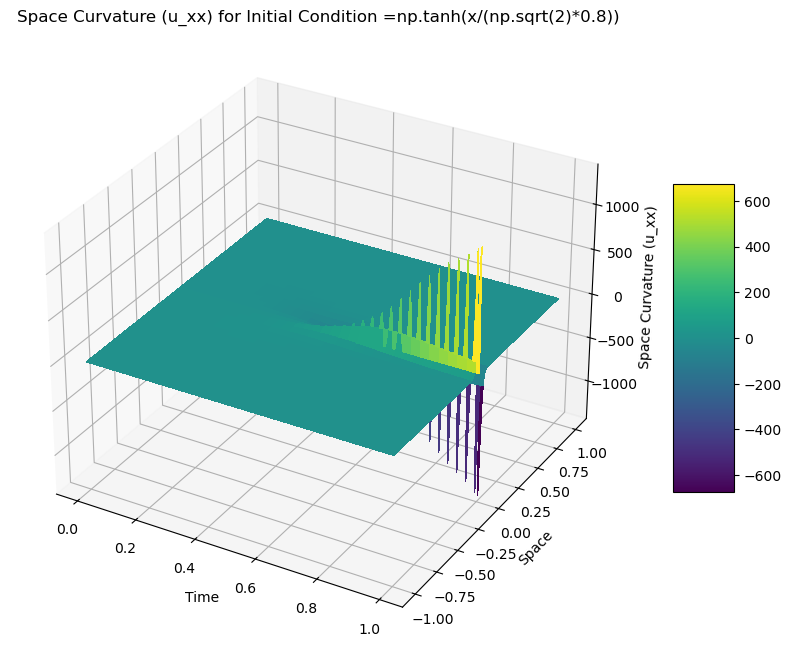

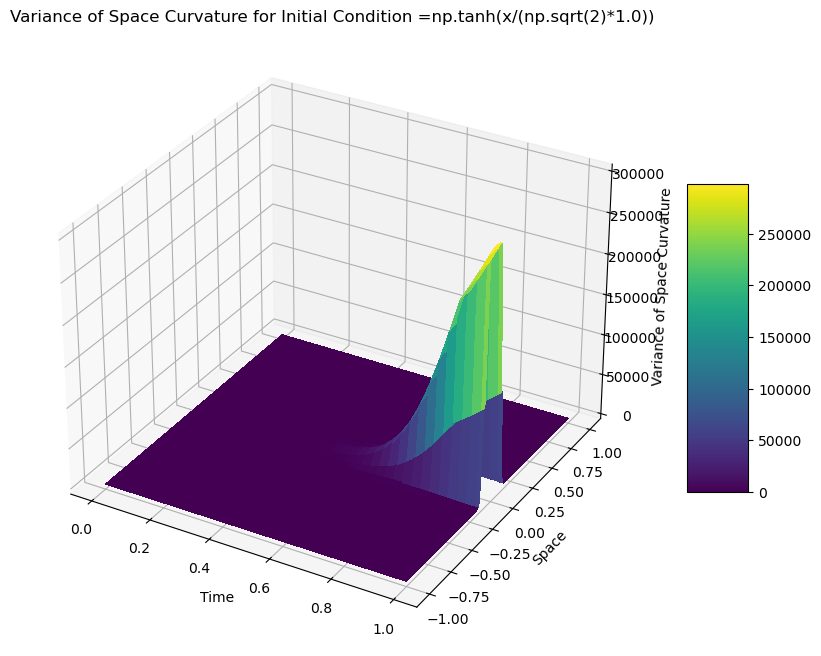

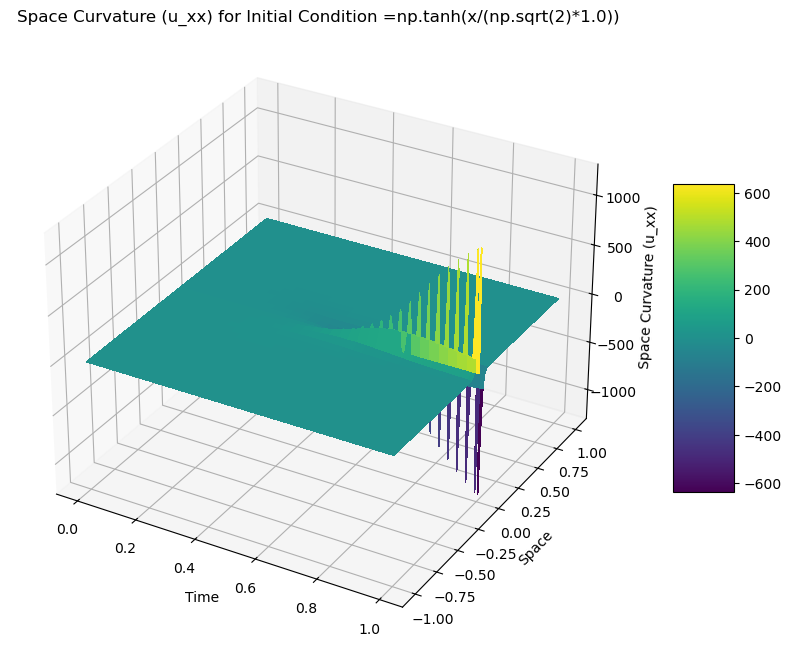

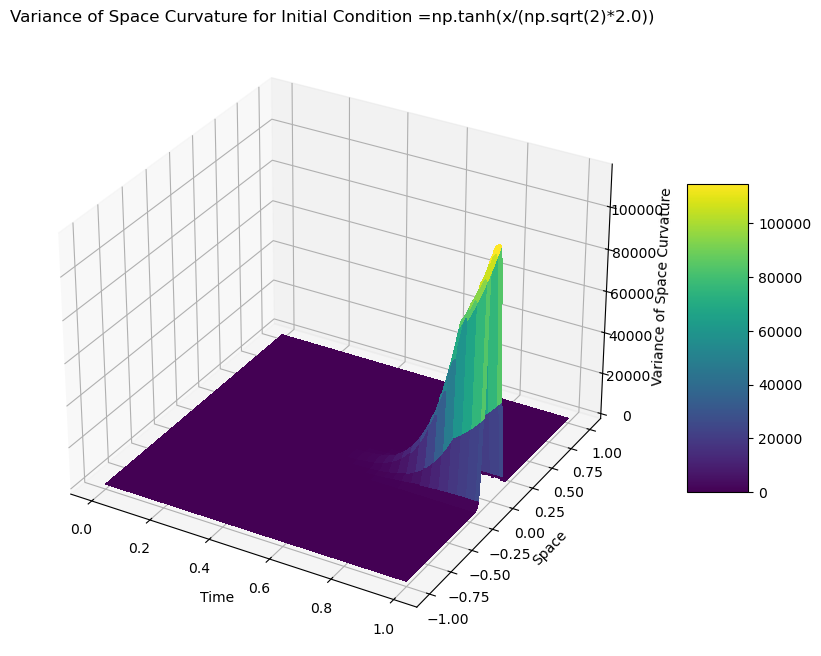

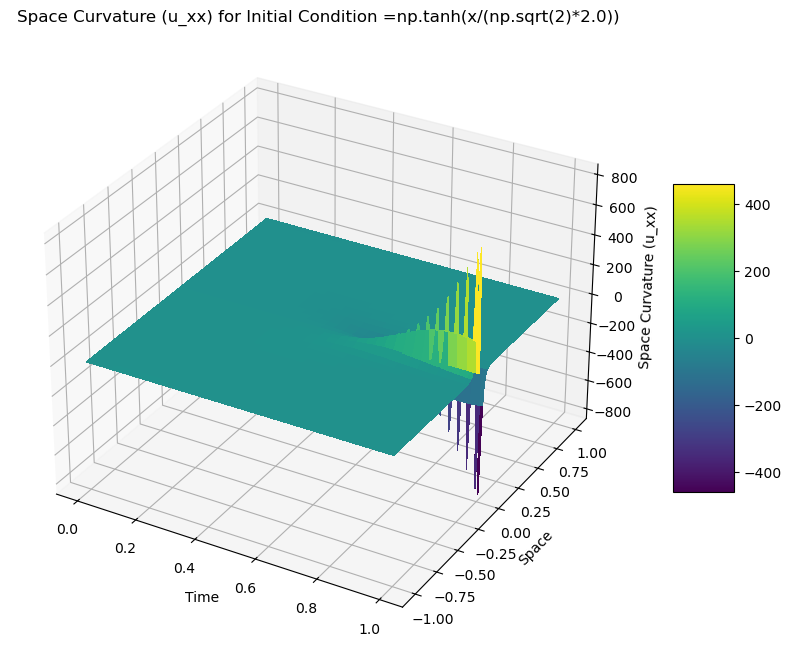

In [10]:
for eps in path_eps_vals:
    mat_path = f"../Datasets/data/Diff_Curvature_ghost_pts/Allen_Cahn_tanh_{eps}.mat"
    variance_space_curvature = get_variance_space_curvature(mat_path)

    import matplotlib.pyplot as plt
    import numpy as np

    from matplotlib import cm
    from matplotlib.ticker import LinearLocator

    space_var = np.linspace(-1, 1, variance_space_curvature.shape[1])
    time_var = np.linspace(0, 1, variance_space_curvature.shape[0])
    time_var, space_var = np.meshgrid(time_var, space_var)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 8))
    surf = ax.plot_surface(time_var, space_var, variance_space_curvature.T, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax.set_xlabel('Time')
    ax.set_ylabel('Space')
    ax.set_zlabel('Variance of Space Curvature')
    ax.set_title(f'Variance of Space Curvature for Initial Condition =np.tanh(x/(np.sqrt(2)*{eps}))')
    fig.colorbar(surf, shrink=0.5, aspect=5)

    uxx = sio.loadmat(mat_path)['u_xx']
    space = np.linspace(-1, 1, uxx.shape[1])
    time = np.linspace(0, 1, uxx.shape[0])
    time, space = np.meshgrid(time, space)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(12, 8))
    surf = ax.plot_surface(time, space, uxx.T, cmap=cm.viridis, linewidth=0, antialiased=False)
    ax.set_xlabel('Time')
    ax.set_ylabel('Space')
    ax.set_zlabel('Space Curvature (u_xx)')
    ax.set_title(f'Space Curvature (u_xx) for Initial Condition =np.tanh(x/(np.sqrt(2)*{eps}))')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()